In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# **BBCC CIRA CIC DOHBRW 2020**

In [12]:
df = pd.read_csv("datasets\\bccc_cira_cic_dohbrw_2020.csv") 

In [13]:
df.shape

(499106, 29)

In [14]:
"28 num var + 1 str var (response)"
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 499106 entries, 0 to 499105
Data columns (total 29 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   FlowBytesSent                           499106 non-null  int64  
 1   FlowSentRate                            499106 non-null  float64
 2   FlowBytesReceived                       499106 non-null  int64  
 3   FlowReceivedRate                        499106 non-null  float64
 4   PacketLengthVariance                    499106 non-null  float64
 5   PacketLengthStandardDeviation           499106 non-null  float64
 6   PacketLengthMean                        499106 non-null  float64
 7   PacketLengthMedian                      499106 non-null  float64
 8   PacketLengthMode                        499106 non-null  int64  
 9   PacketLengthSkewFromMedian              499106 non-null  float64
 10  PacketLengthSkewFromMode                499106 non-null

In [15]:
df.isnull().sum()

FlowBytesSent                             0
FlowSentRate                              0
FlowBytesReceived                         0
FlowReceivedRate                          0
PacketLengthVariance                      0
PacketLengthStandardDeviation             0
PacketLengthMean                          0
PacketLengthMedian                        0
PacketLengthMode                          0
PacketLengthSkewFromMedian                0
PacketLengthSkewFromMode                  0
PacketLengthCoefficientofVariation        0
PacketTimeVariance                        0
PacketTimeStandardDeviation               0
PacketTimeMean                            0
PacketTimeMedian                          0
PacketTimeMode                            0
PacketTimeSkewFromMedian                  0
PacketTimeSkewFromMode                    0
PacketTimeCoefficientofVariation          0
ResponseTimeTimeVariance                  0
ResponseTimeTimeStandardDeviation         0
ResponseTimeTimeMean            

In [16]:
df.head(1).T

,0
FlowBytesSent,353
FlowSentRate,80.890348
FlowBytesReceived,393
FlowReceivedRate,90.056393
PacketLengthVariance,469.209877
PacketLengthStandardDeviation,21.661253
PacketLengthMean,82.888889
PacketLengthMedian,66.0
PacketLengthMode,66
PacketLengthSkewFromMedian,2.339046


In [17]:
df_num = df.select_dtypes(include=['number'])
df_cat = df.select_dtypes(exclude=['number'])

In [18]:
df_cat['Label'].value_counts()

Label
Benign       249553
Malicious    249553
Name: count, dtype: int64

In [19]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
FlowBytesSent,499106.0,40200.925483,143961.655790,5.500000e+01,618.000000,1807.000000,5542.000000,8.015359e+06
FlowSentRate,499106.0,47339.147444,421275.128880,1.464903e+00,54.107811,364.096931,3810.259664,2.304348e+07
FlowBytesReceived,499106.0,42501.556227,139392.708614,5.400000e+01,476.000000,4827.000000,7888.000000,7.723184e+06
FlowReceivedRate,499106.0,31668.292337,256680.472304,1.576245e+00,141.812836,461.114551,4215.497773,7.600000e+06
PacketLengthVariance,499106.0,92635.849630,153493.758127,0.000000e+00,469.209877,18267.886503,141598.912222,1.578115e+06
PacketLengthStandardDeviation,499106.0,220.169083,210.141825,0.000000e+00,21.661253,135.142971,376.296309,1.256231e+03
PacketLengthMean,499106.0,173.159814,85.506490,5.600000e+01,92.000000,152.488283,228.758621,6.898000e+02
PacketLengthMedian,499106.0,95.472702,32.999740,5.400000e+01,76.000000,87.000000,105.000000,3.170000e+02
PacketLengthMode,499106.0,70.749953,14.830277,5.400000e+01,66.000000,68.000000,68.000000,5.530000e+02
PacketLengthSkewFromMedian,499106.0,0.442934,1.551998,-1.000000e+01,0.199848,0.986397,1.201609,2.932375e+00


In [20]:
df_num.corr()

,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,PacketLengthVariance,PacketLengthStandardDeviation,PacketLengthMean,PacketLengthMedian,PacketLengthMode,PacketLengthSkewFromMedian,...,PacketTimeSkewFromMode,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation
FlowBytesSent,1.000000,-0.027537,0.815642,-0.029200,-0.125260,-0.121286,-0.038375,0.282036,-0.038400,0.042441,...,-0.003568,-0.202211,-0.040391,-0.055171,-0.054637,-0.045478,-0.032371,0.126485,0.037997,0.440981
FlowSentRate,-0.027537,1.000000,-0.030958,0.994330,-0.063464,-0.100646,-0.112469,-0.044428,-0.066774,-0.028486,...,-0.029392,-0.000057,-0.017295,-0.028733,-0.023904,-0.018816,-0.013394,-0.300554,-0.326855,-0.067198
FlowBytesReceived,0.815642,-0.030958,1.000000,-0.031073,-0.123848,-0.114174,-0.012396,0.370265,-0.036229,0.037382,...,0.019390,-0.208003,-0.043357,-0.063058,-0.060469,-0.049238,-0.034960,0.110233,0.045015,0.259427
FlowReceivedRate,-0.029200,0.994330,-0.031073,1.000000,-0.049494,-0.089524,-0.099818,-0.046553,-0.068310,-0.023304,...,-0.019066,-0.008451,-0.018952,-0.031398,-0.026166,-0.020591,-0.014698,-0.298879,-0.322588,-0.068752
PacketLengthVariance,-0.125260,-0.063464,-0.123848,-0.049494,1.000000,0.915403,0.845969,-0.216173,-0.164969,0.271415,...,-0.163580,0.279322,-0.019242,-0.047781,-0.096472,-0.096820,-0.071382,0.064658,0.231762,-0.044358
PacketLengthStandardDeviation,-0.121286,-0.100646,-0.114174,-0.089524,0.915403,1.000000,0.939291,-0.179838,-0.265381,0.415582,...,-0.263729,0.439985,-0.023060,-0.074818,-0.164639,-0.163849,-0.122509,0.143830,0.349109,-0.002290
PacketLengthMean,-0.038375,-0.112469,-0.012396,-0.099818,0.845969,0.939291,1.000000,0.022232,-0.254979,0.430143,...,-0.185222,0.352104,-0.037748,-0.097487,-0.203821,-0.200964,-0.150970,0.195822,0.359610,0.040978
PacketLengthMedian,0.282036,-0.044428,0.370265,-0.046553,-0.216173,-0.179838,0.022232,1.000000,0.148676,-0.169817,...,0.145118,-0.166792,-0.075071,-0.087071,-0.156990,-0.149564,-0.111617,0.140681,0.002990,0.168839
PacketLengthMode,-0.038400,-0.066774,-0.036229,-0.068310,-0.164969,-0.265381,-0.254979,0.148676,1.000000,-0.525916,...,0.000075,-0.101416,-0.083578,-0.086803,-0.089638,-0.071645,-0.063864,-0.196590,-0.246000,-0.127209
PacketLengthSkewFromMedian,0.042441,-0.028486,0.037382,-0.023304,0.271415,0.415582,0.430143,-0.169817,-0.525916,1.000000,...,-0.040562,0.156318,0.053003,0.055396,-0.277925,-0.242724,-0.366302,0.273067,0.336987,0.166317


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\4072513135.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='FlowBytesSent', ax=axes[2], palette=['green', 'red'])


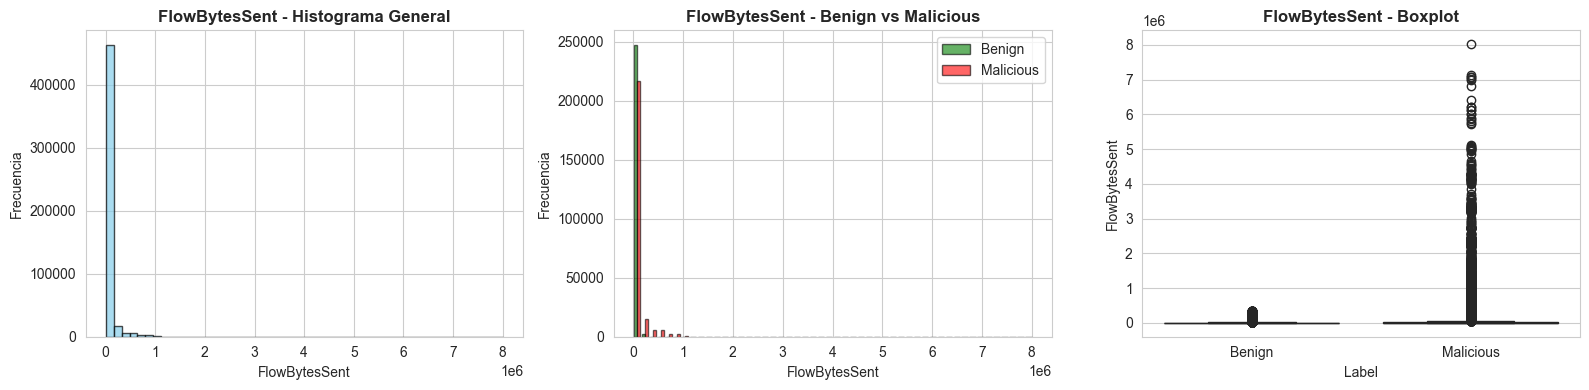

Benign - Mean: 10150.98, Std: 29947.29
Malicious - Mean: 70250.87, Std: 196842.97


In [29]:
"""
1
FlowBytesSent
Flow features
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma general
axes[0].hist(df['FlowBytesSent'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('FlowBytesSent - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('FlowBytesSent')
axes[0].set_ylabel('Frecuencia')

# Histograma por clase
df_benign = df[df['Label'] == 'Benign']['FlowBytesSent']
df_malicious = df[df['Label'] == 'Malicious']['FlowBytesSent']

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('FlowBytesSent - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('FlowBytesSent')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# Boxplot
sns.boxplot(data=df, x='Label', y='FlowBytesSent', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('FlowBytesSent - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('FlowBytesSent')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\3607814556.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='FlowSentRate', ax=axes[2], palette=['green', 'red'])


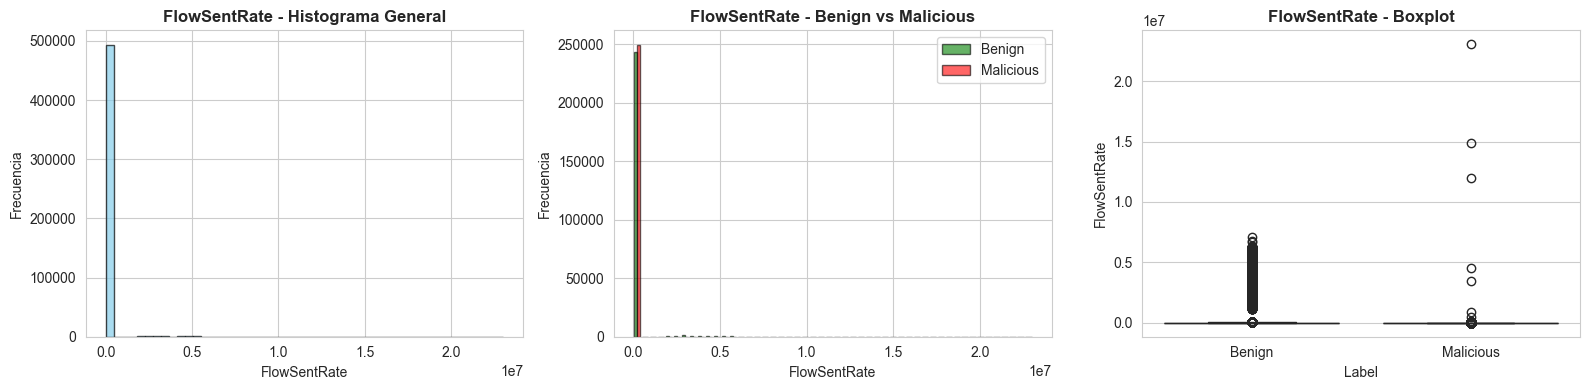

Benign - Mean: 93141.76, Std: 589083.17
Malicious - Mean: 1536.53, Std: 61085.32


In [30]:
"""
2
FlowSentRate
Flow features
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['FlowSentRate']
df_malicious = df[df['Label'] == 'Malicious']['FlowSentRate']

axes[0].hist(df['FlowSentRate'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('FlowSentRate - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('FlowSentRate')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('FlowSentRate - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('FlowSentRate')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='FlowSentRate', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('FlowSentRate - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('FlowSentRate')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\1026631496.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='FlowBytesReceived', ax=axes[2], palette=['green', 'red'])


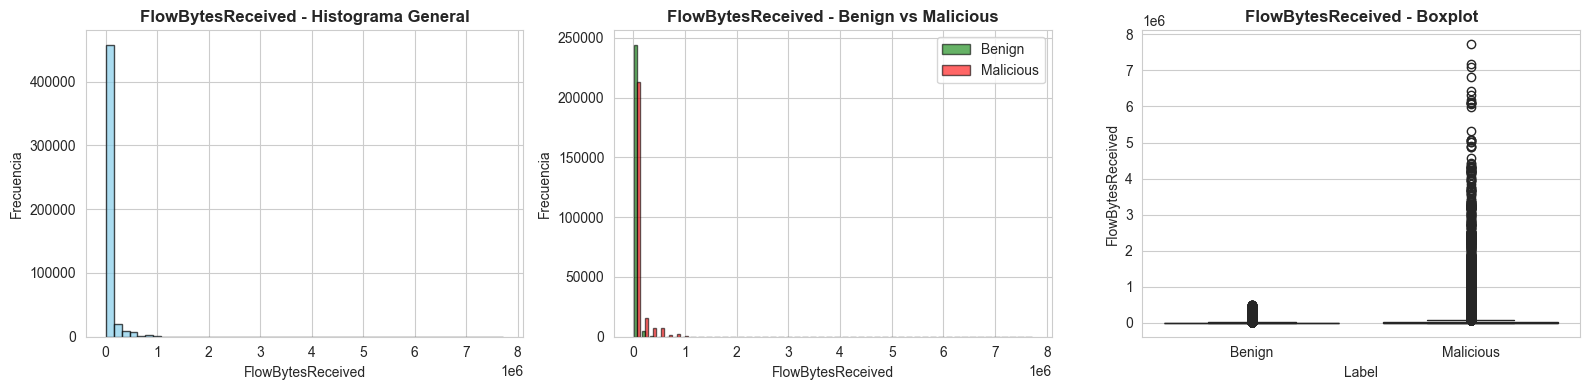

Benign - Mean: 13262.00, Std: 40677.19
Malicious - Mean: 71741.11, Std: 188404.32


In [31]:
"""
3
FlowBytesReceived
Flow features
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['FlowBytesReceived']
df_malicious = df[df['Label'] == 'Malicious']['FlowBytesReceived']

axes[0].hist(df['FlowBytesReceived'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('FlowBytesReceived - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('FlowBytesReceived')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('FlowBytesReceived - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('FlowBytesReceived')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='FlowBytesReceived', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('FlowBytesReceived - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('FlowBytesReceived')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2139192741.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='FlowReceivedRate', ax=axes[2], palette=['green', 'red'])


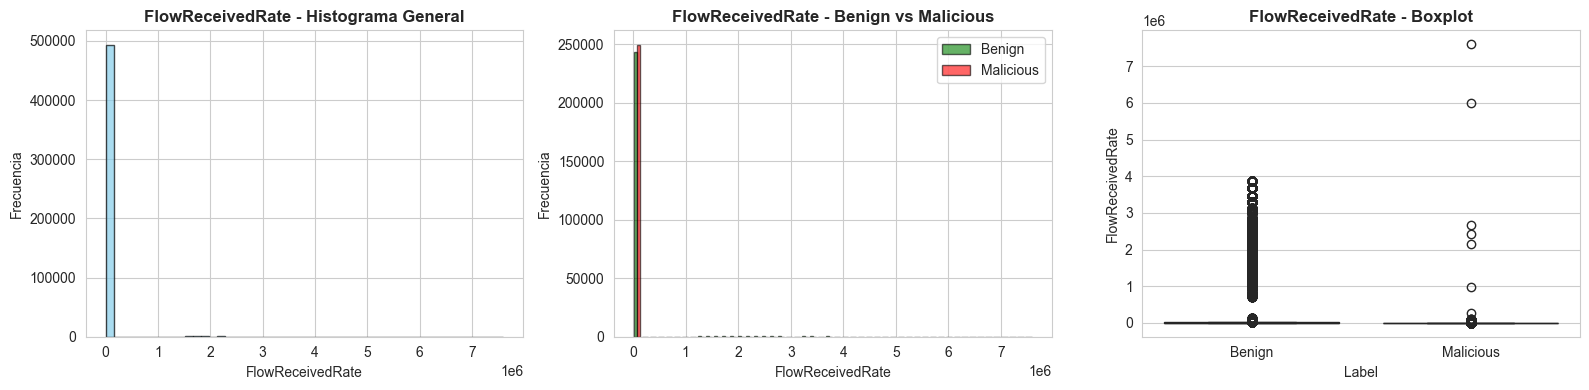

Benign - Mean: 60465.06, Std: 360014.63
Malicious - Mean: 2871.53, Std: 22381.86


In [32]:
"""
4
FlowReceivedRate
Flow features
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['FlowReceivedRate']
df_malicious = df[df['Label'] == 'Malicious']['FlowReceivedRate']

axes[0].hist(df['FlowReceivedRate'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('FlowReceivedRate - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('FlowReceivedRate')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('FlowReceivedRate - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('FlowReceivedRate')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='FlowReceivedRate', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('FlowReceivedRate - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('FlowReceivedRate')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\3142972551.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthVariance', ax=axes[2], palette=['green', 'red'])


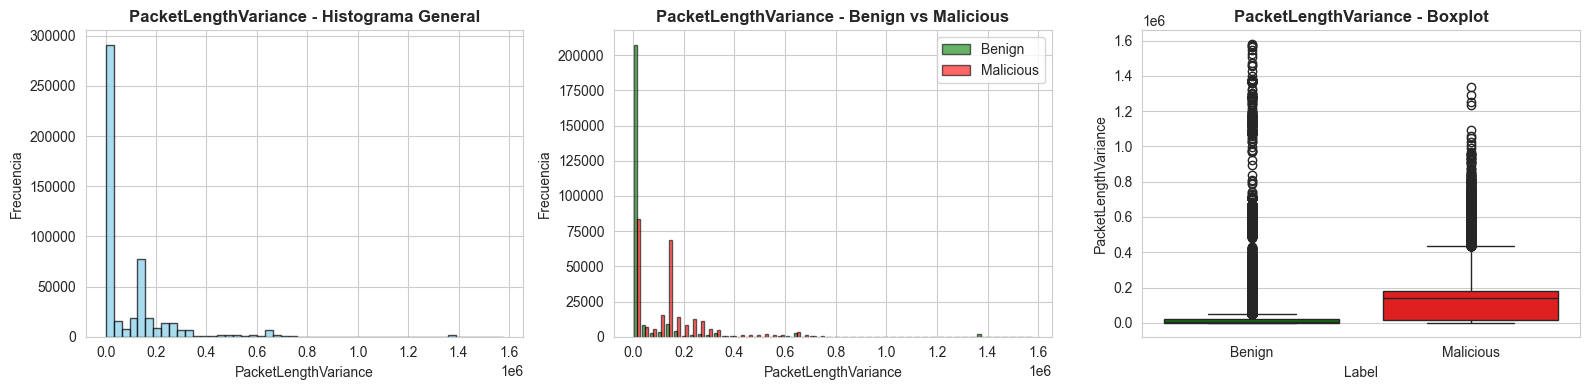

Benign - Mean: 49417.59, Std: 156705.16
Malicious - Mean: 135854.11, Std: 137217.36


In [33]:
"""
5
PacketLengthVariance
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthVariance']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthVariance']

axes[0].hist(df['PacketLengthVariance'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthVariance - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthVariance')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthVariance - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthVariance')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthVariance', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthVariance - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthVariance')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2488159636.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthStandardDeviation', ax=axes[2], palette=['green', 'red'])


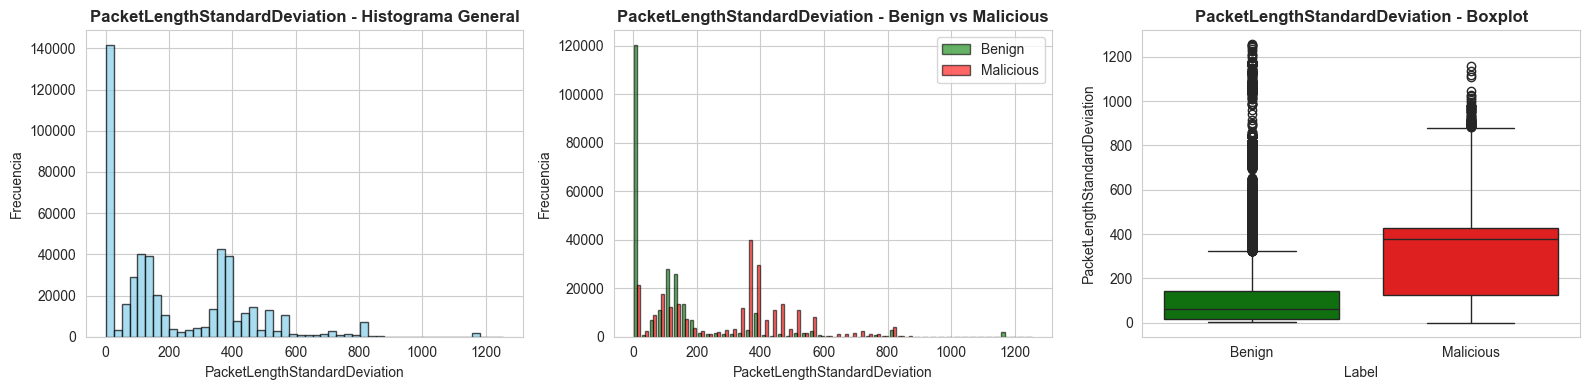

Benign - Mean: 127.26, Std: 182.26
Malicious - Mean: 313.07, Std: 194.52


In [34]:
"""
6
PacketLengthStandardDeviation
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthStandardDeviation']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthStandardDeviation']

axes[0].hist(df['PacketLengthStandardDeviation'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthStandardDeviation - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthStandardDeviation')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthStandardDeviation - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthStandardDeviation')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthStandardDeviation', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthStandardDeviation - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthStandardDeviation')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\1575516081.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthMean', ax=axes[2], palette=['green', 'red'])


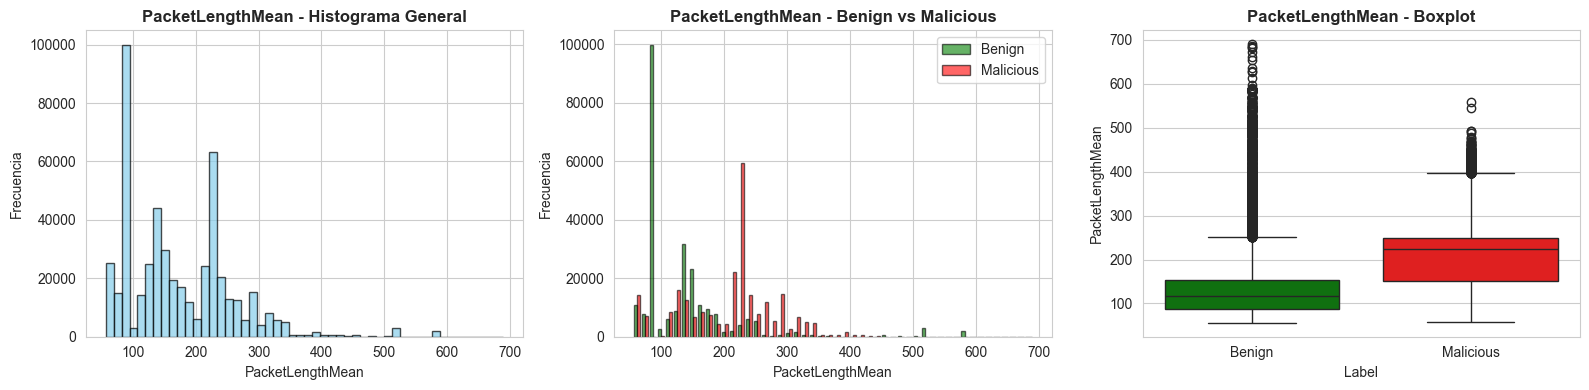

Benign - Mean: 137.60, Std: 81.63
Malicious - Mean: 208.72, Std: 73.70


In [35]:
"""
7
PacketLengthMean
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthMean']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthMean']

axes[0].hist(df['PacketLengthMean'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthMean - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthMean')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthMean - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthMean')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthMean', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthMean - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthMean')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\548555159.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthMedian', ax=axes[2], palette=['green', 'red'])


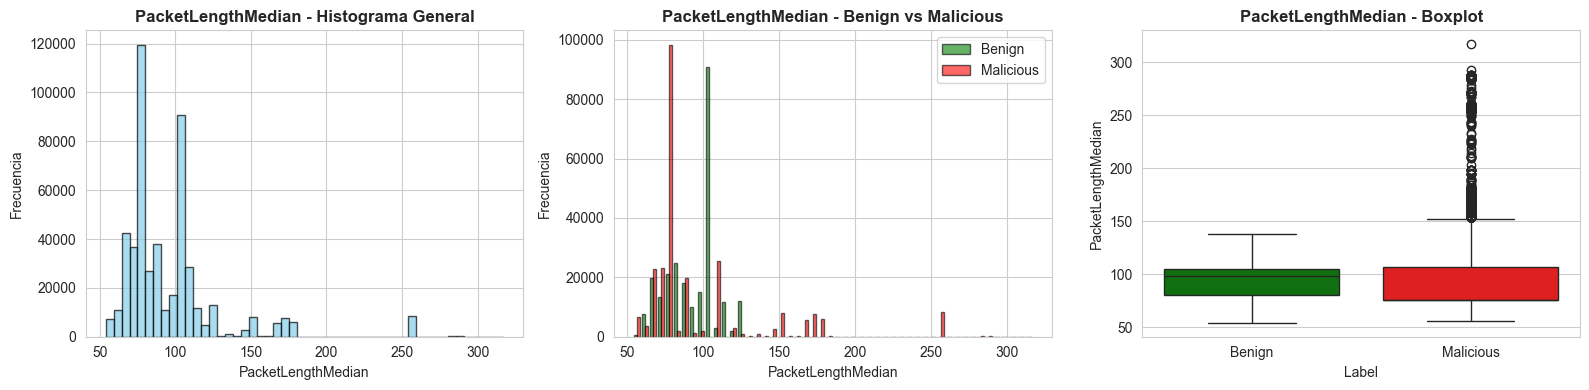

Benign - Mean: 93.90, Std: 16.31
Malicious - Mean: 97.05, Std: 43.67


In [36]:
"""
8
PacketLengthMedian
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthMedian']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthMedian']

axes[0].hist(df['PacketLengthMedian'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthMedian - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthMedian')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthMedian - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthMedian')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthMedian', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthMedian - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthMedian')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2280803618.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthMode', ax=axes[2], palette=['green', 'red'])


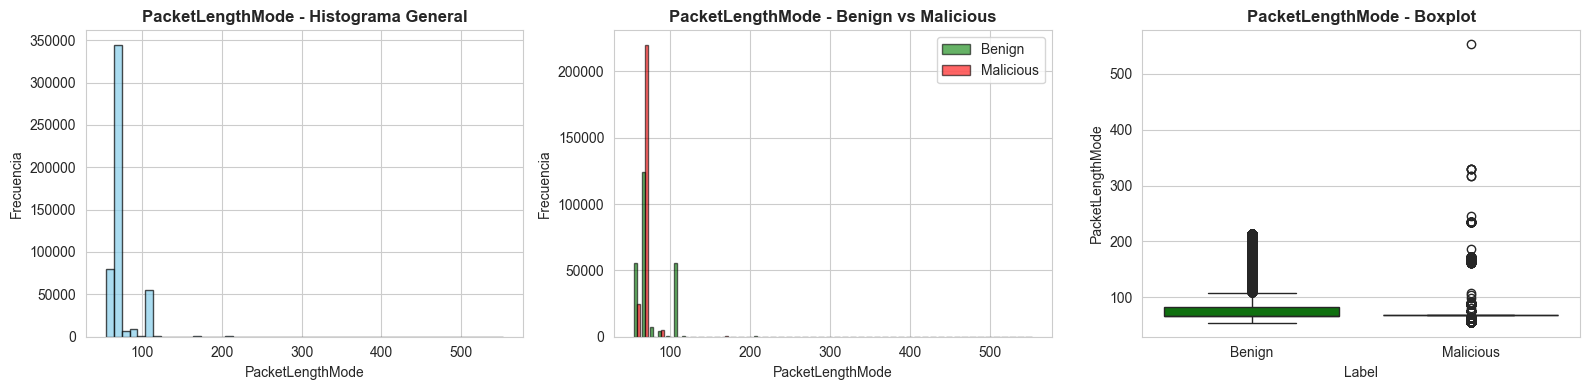

Benign - Mean: 73.99, Std: 19.49
Malicious - Mean: 67.51, Std: 6.24


In [37]:
"""
9
PacketLengthMode
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthMode']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthMode']

axes[0].hist(df['PacketLengthMode'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthMode - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthMode')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthMode - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthMode')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthMode', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthMode - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthMode')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\3340951590.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthSkewFromMedian', ax=axes[2], palette=['green', 'red'])


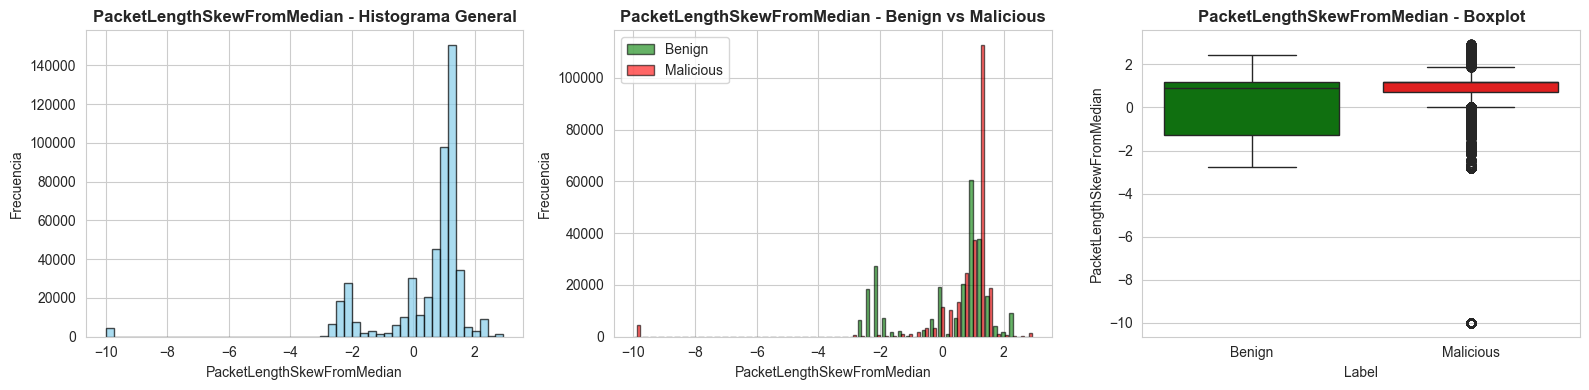

Benign - Mean: 0.16, Std: 1.46
Malicious - Mean: 0.73, Std: 1.59


In [38]:
"""
10
PacketLengthSkewFromMedian
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthSkewFromMedian']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthSkewFromMedian']

axes[0].hist(df['PacketLengthSkewFromMedian'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthSkewFromMedian - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthSkewFromMedian')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthSkewFromMedian - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthSkewFromMedian')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthSkewFromMedian', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthSkewFromMedian - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthSkewFromMedian')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2416511067.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthSkewFromMode', ax=axes[2], palette=['green', 'red'])


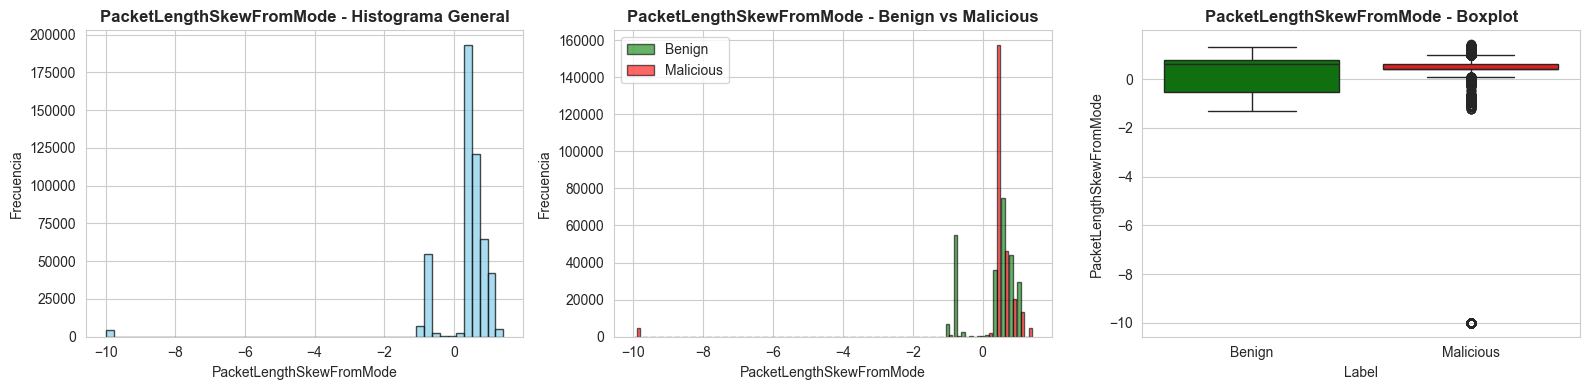

Benign - Mean: 0.33, Std: 0.65
Malicious - Mean: 0.33, Std: 1.44


In [39]:
"""
11
PacketLengthSkewFromMode
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthSkewFromMode']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthSkewFromMode']

axes[0].hist(df['PacketLengthSkewFromMode'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthSkewFromMode - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthSkewFromMode')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthSkewFromMode - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthSkewFromMode')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthSkewFromMode', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthSkewFromMode - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthSkewFromMode')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\64386720.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketLengthCoefficientofVariation', ax=axes[2], palette=['green', 'red'])


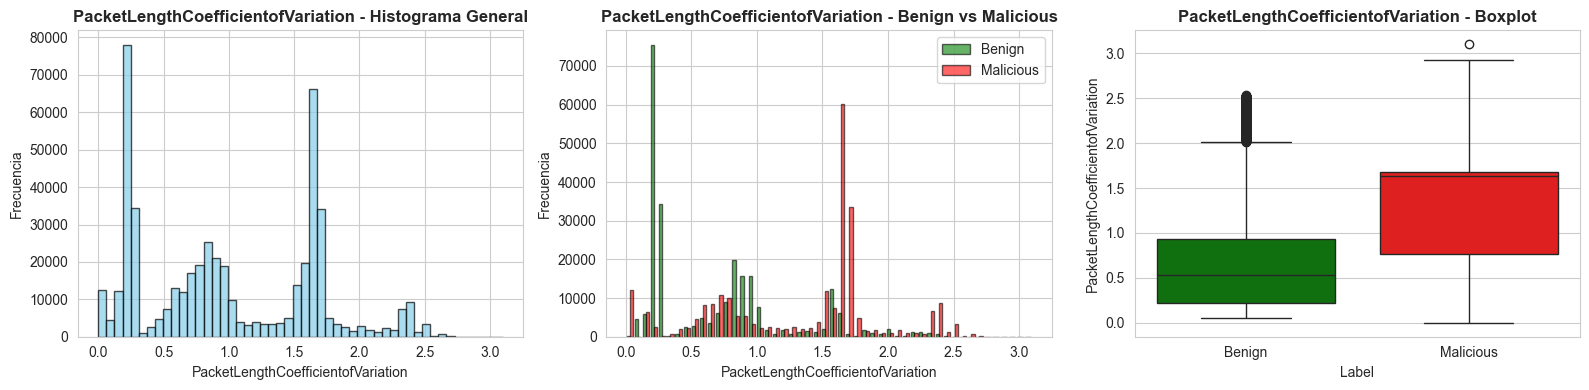

Benign - Mean: 0.66, Std: 0.53
Malicious - Mean: 1.33, Std: 0.63


In [40]:
"""
12
PacketLengthCoefficientofVariation
PACKET LENGTH FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketLengthCoefficientofVariation']
df_malicious = df[df['Label'] == 'Malicious']['PacketLengthCoefficientofVariation']

axes[0].hist(df['PacketLengthCoefficientofVariation'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketLengthCoefficientofVariation - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketLengthCoefficientofVariation')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketLengthCoefficientofVariation - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketLengthCoefficientofVariation')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketLengthCoefficientofVariation', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketLengthCoefficientofVariation - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketLengthCoefficientofVariation')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\1000094245.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeVariance', ax=axes[2], palette=['green', 'red'])


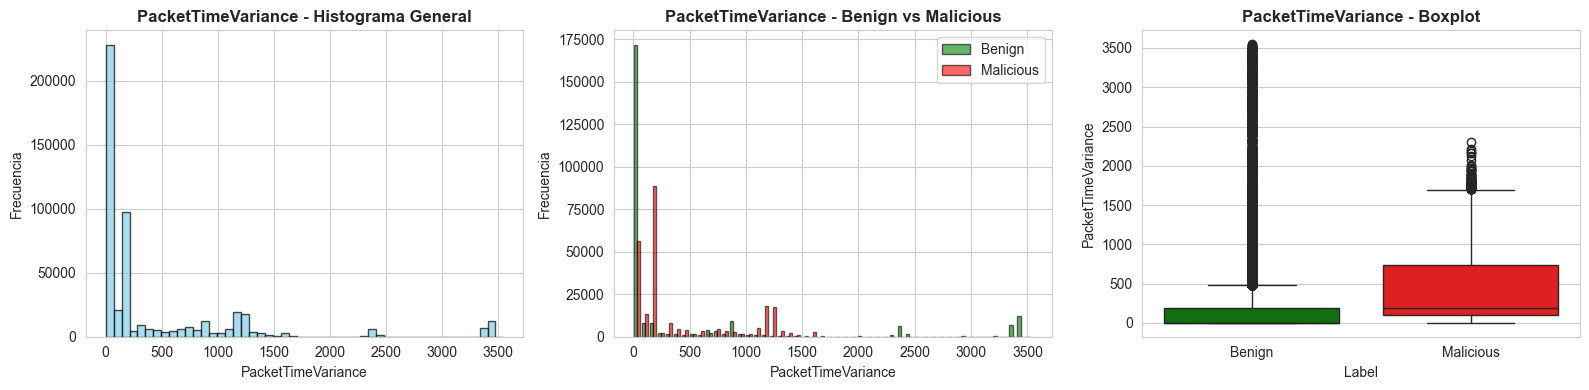

Benign - Mean: 460.71, Std: 988.13
Malicious - Mean: 419.51, Std: 466.91


In [41]:
"""
13
PacketTimeVariance
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeVariance']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeVariance']

axes[0].hist(df['PacketTimeVariance'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeVariance - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeVariance')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeVariance - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeVariance')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeVariance', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeVariance - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeVariance')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\3085976101.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeStandardDeviation', ax=axes[2], palette=['green', 'red'])


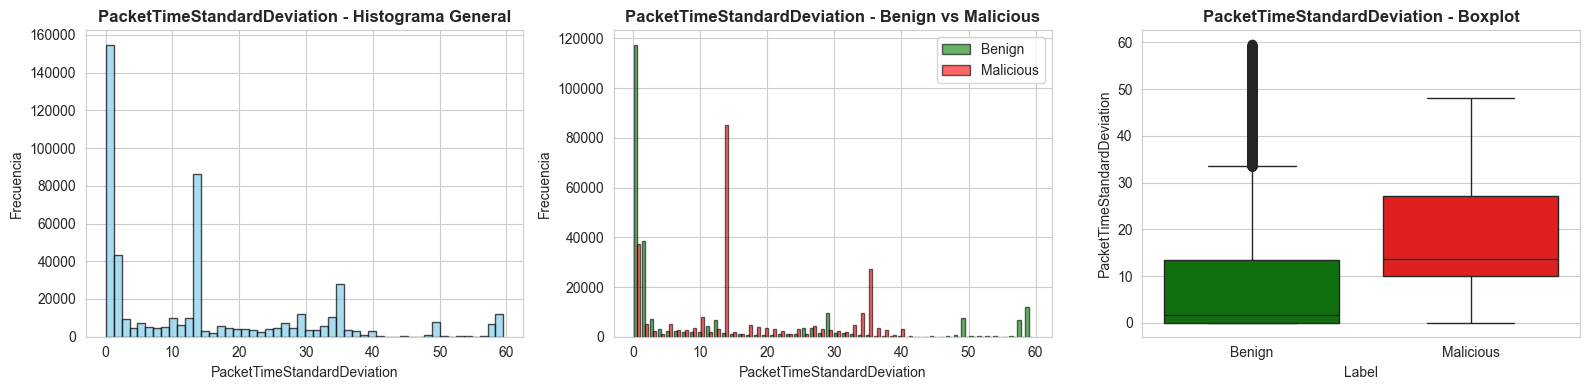

Benign - Mean: 11.20, Std: 18.26
Malicious - Mean: 16.74, Std: 11.80


In [42]:
"""
14
PacketTimeStandardDeviation
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeStandardDeviation']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeStandardDeviation']

axes[0].hist(df['PacketTimeStandardDeviation'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeStandardDeviation - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeStandardDeviation')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeStandardDeviation - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeStandardDeviation')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeStandardDeviation', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeStandardDeviation - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeStandardDeviation')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\256285592.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeMean', ax=axes[2], palette=['green', 'red'])


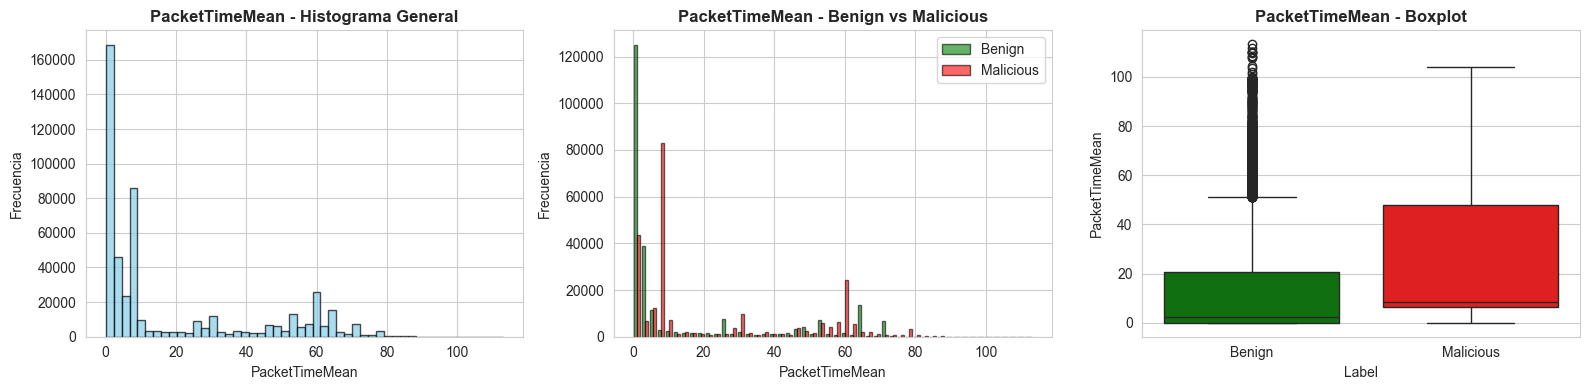

Benign - Mean: 13.94, Std: 22.46
Malicious - Mean: 22.95, Std: 24.24


In [43]:
"""
15
PacketTimeMean
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeMean']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeMean']

axes[0].hist(df['PacketTimeMean'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeMean - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeMean')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeMean - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeMean')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeMean', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeMean - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeMean')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\3591247474.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeMedian', ax=axes[2], palette=['green', 'red'])


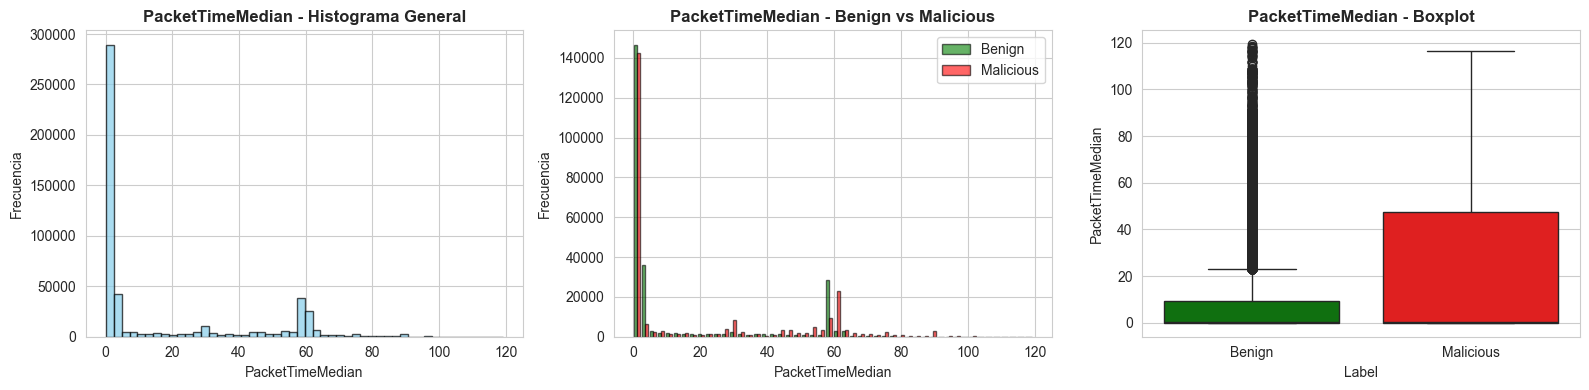

Benign - Mean: 12.80, Std: 22.14
Malicious - Mean: 20.15, Std: 27.36


In [44]:
"""
16
PacketTimeMedian
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeMedian']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeMedian']

axes[0].hist(df['PacketTimeMedian'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeMedian - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeMedian')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeMedian - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeMedian')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeMedian', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeMedian - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeMedian')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\3067305636.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeMode', ax=axes[2], palette=['green', 'red'])


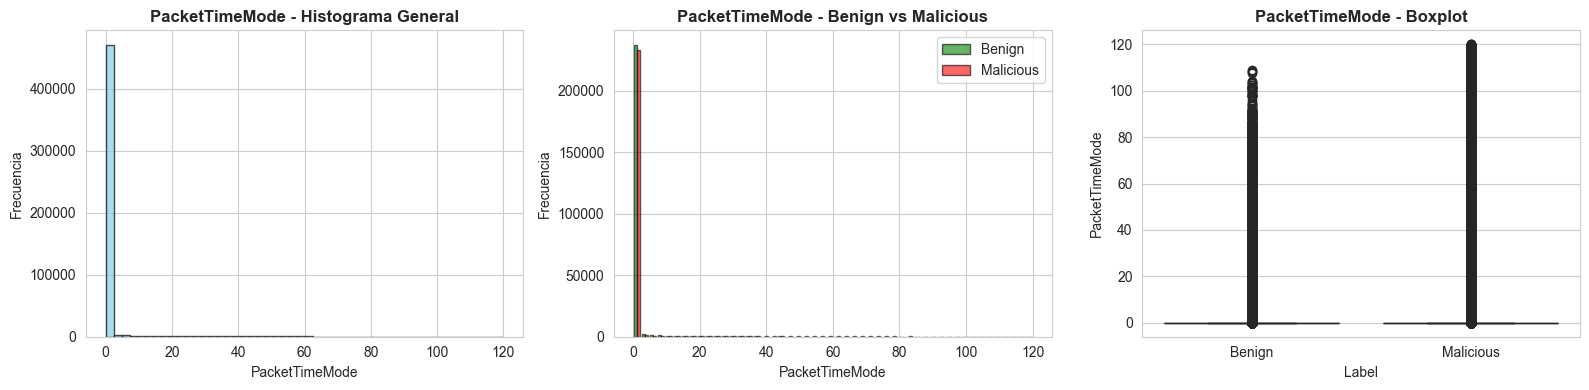

Benign - Mean: 1.05, Std: 6.13
Malicious - Mean: 2.60, Std: 12.34


In [45]:
"""
17
PacketTimeMode
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeMode']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeMode']

axes[0].hist(df['PacketTimeMode'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeMode - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeMode')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeMode - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeMode')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeMode', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeMode - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeMode')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\1656749634.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeSkewFromMedian', ax=axes[2], palette=['green', 'red'])


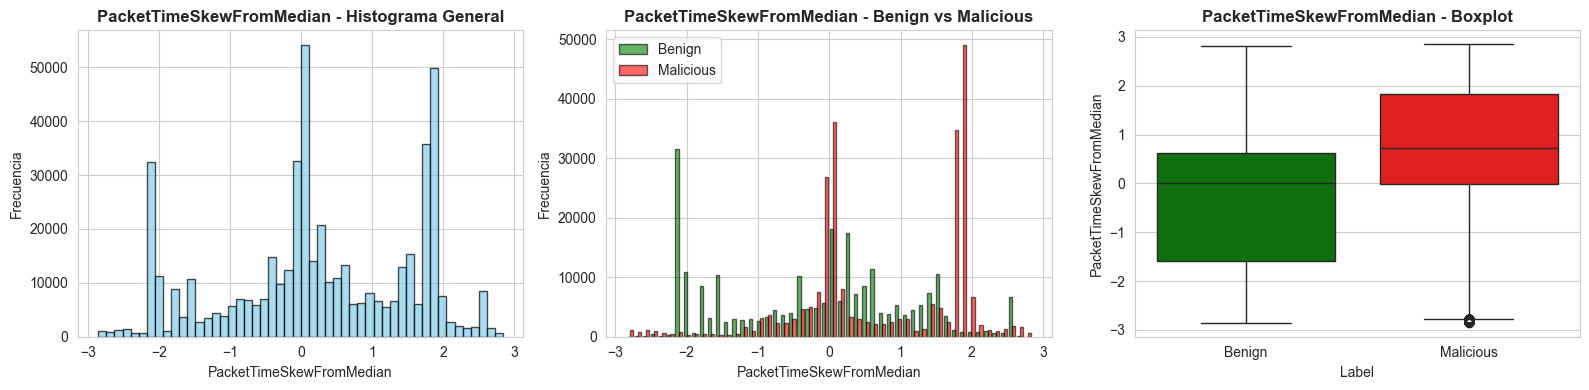

Benign - Mean: -0.21, Std: 1.31
Malicious - Mean: 0.76, Std: 1.13


In [46]:
"""
19
PacketTimeSkewFromMedian
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeSkewFromMedian']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeSkewFromMedian']

axes[0].hist(df['PacketTimeSkewFromMedian'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeSkewFromMedian - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeSkewFromMedian')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeSkewFromMedian - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeSkewFromMedian')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeSkewFromMedian', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeSkewFromMedian - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeSkewFromMedian')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2652433315.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeSkewFromMode', ax=axes[2], palette=['green', 'red'])


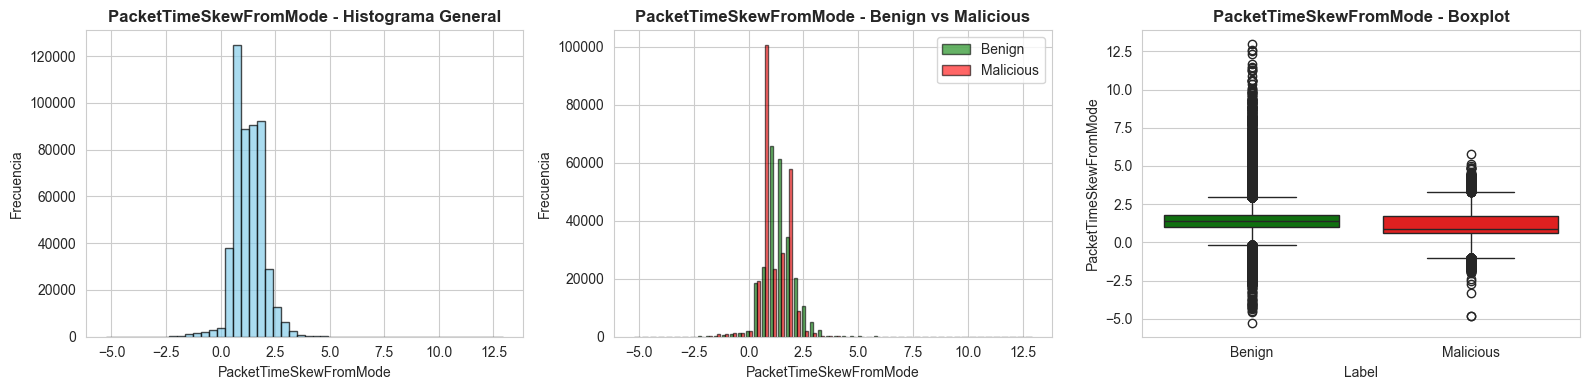

Benign - Mean: 1.40, Std: 0.74
Malicious - Mean: 1.09, Std: 0.65


In [47]:
"""
20
PacketTimeSkewFromMode
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeSkewFromMode']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeSkewFromMode']

axes[0].hist(df['PacketTimeSkewFromMode'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeSkewFromMode - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeSkewFromMode')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeSkewFromMode - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeSkewFromMode')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeSkewFromMode', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeSkewFromMode - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeSkewFromMode')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2122909279.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='PacketTimeCoefficientofVariation', ax=axes[2], palette=['green', 'red'])


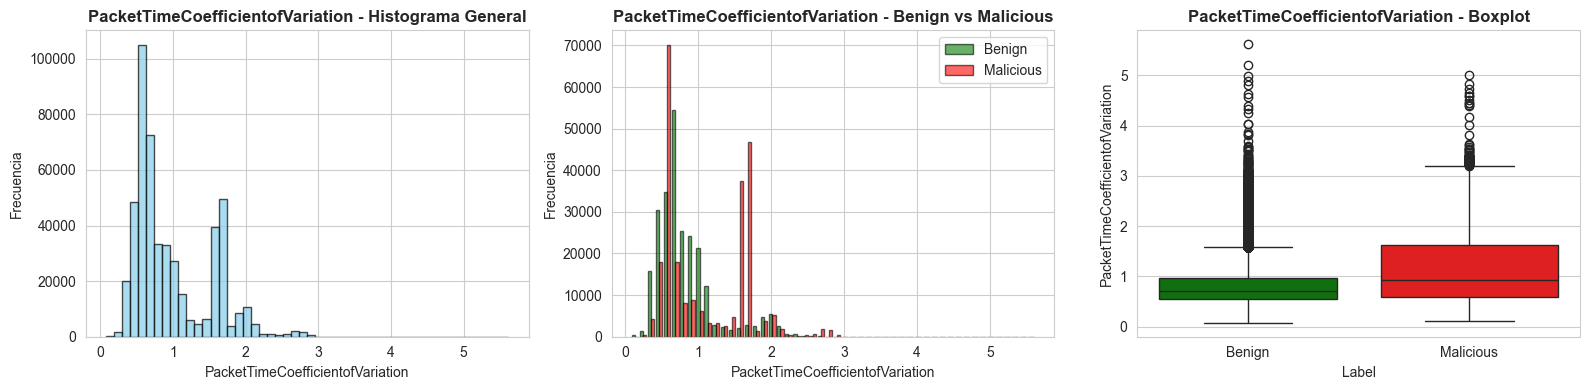

Benign - Mean: 0.83, Std: 0.42
Malicious - Mean: 1.11, Std: 0.57


In [48]:
"""
21
PacketTimeCoefficientofVariation
PACKET TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['PacketTimeCoefficientofVariation']
df_malicious = df[df['Label'] == 'Malicious']['PacketTimeCoefficientofVariation']

axes[0].hist(df['PacketTimeCoefficientofVariation'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('PacketTimeCoefficientofVariation - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PacketTimeCoefficientofVariation')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('PacketTimeCoefficientofVariation - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PacketTimeCoefficientofVariation')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='PacketTimeCoefficientofVariation', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('PacketTimeCoefficientofVariation - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('PacketTimeCoefficientofVariation')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2292921492.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeVariance', ax=axes[2], palette=['green', 'red'])


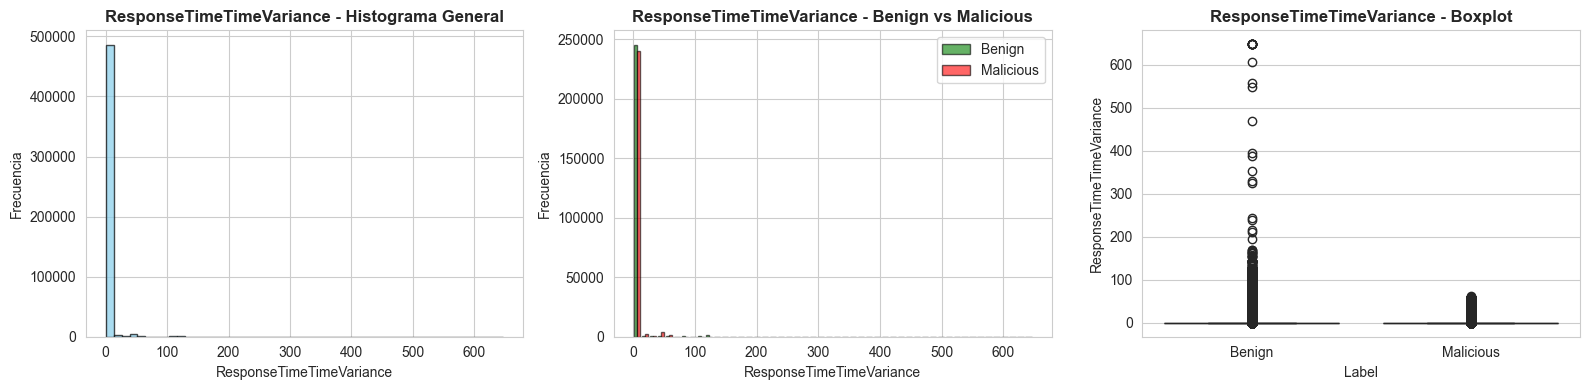

Benign - Mean: 1.91, Std: 13.55
Malicious - Mean: 1.51, Std: 7.93


In [49]:
"""
22
ResponseTimeTimeVariance
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeVariance']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeVariance']

axes[0].hist(df['ResponseTimeTimeVariance'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeVariance - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeVariance')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeVariance - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeVariance')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeVariance', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeVariance - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeVariance')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\4202848717.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeStandardDeviation', ax=axes[2], palette=['green', 'red'])


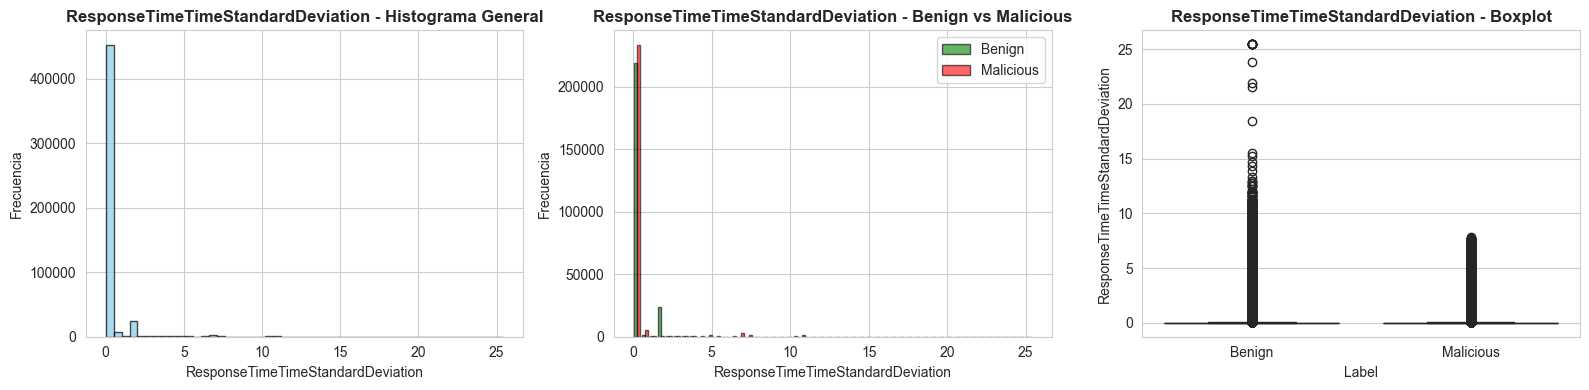

Benign - Mean: 0.34, Std: 1.29
Malicious - Mean: 0.30, Std: 1.19


In [50]:
"""
23
ResponseTimeTimeStandardDeviation
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeStandardDeviation']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeStandardDeviation']

axes[0].hist(df['ResponseTimeTimeStandardDeviation'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeStandardDeviation - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeStandardDeviation')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeStandardDeviation - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeStandardDeviation')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeStandardDeviation', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeStandardDeviation - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeStandardDeviation')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2664601876.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeMean', ax=axes[2], palette=['green', 'red'])


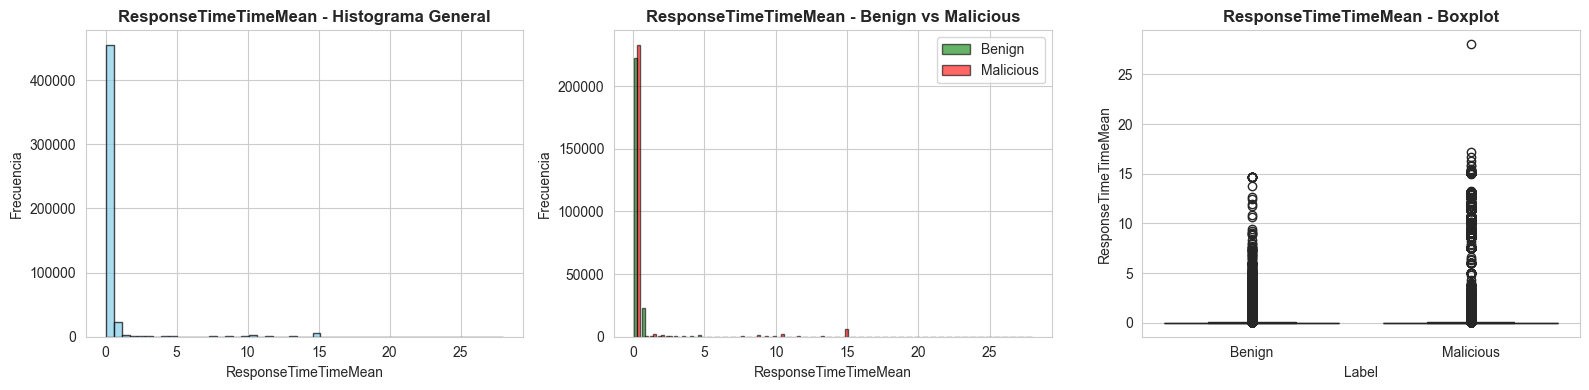

Benign - Mean: 0.17, Std: 0.58
Malicious - Mean: 0.71, Std: 2.85


In [51]:
"""
24
ResponseTimeTimeMean
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeMean']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeMean']

axes[0].hist(df['ResponseTimeTimeMean'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeMean - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeMean')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeMean - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeMean')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeMean', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeMean - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeMean')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\2813457557.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeMedian', ax=axes[2], palette=['green', 'red'])


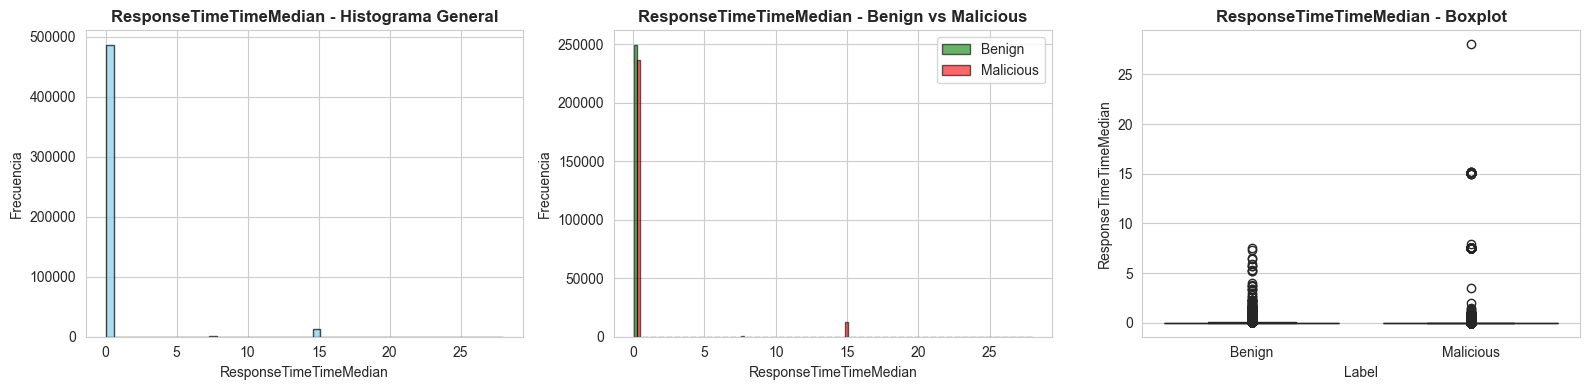

Benign - Mean: 0.02, Std: 0.06
Malicious - Mean: 0.77, Std: 3.28


In [52]:
"""
25
ResponseTimeTimeMedian
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeMedian']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeMedian']

axes[0].hist(df['ResponseTimeTimeMedian'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeMedian - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeMedian')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeMedian - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeMedian')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeMedian', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeMedian - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeMedian')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\1430708316.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeMode', ax=axes[2], palette=['green', 'red'])


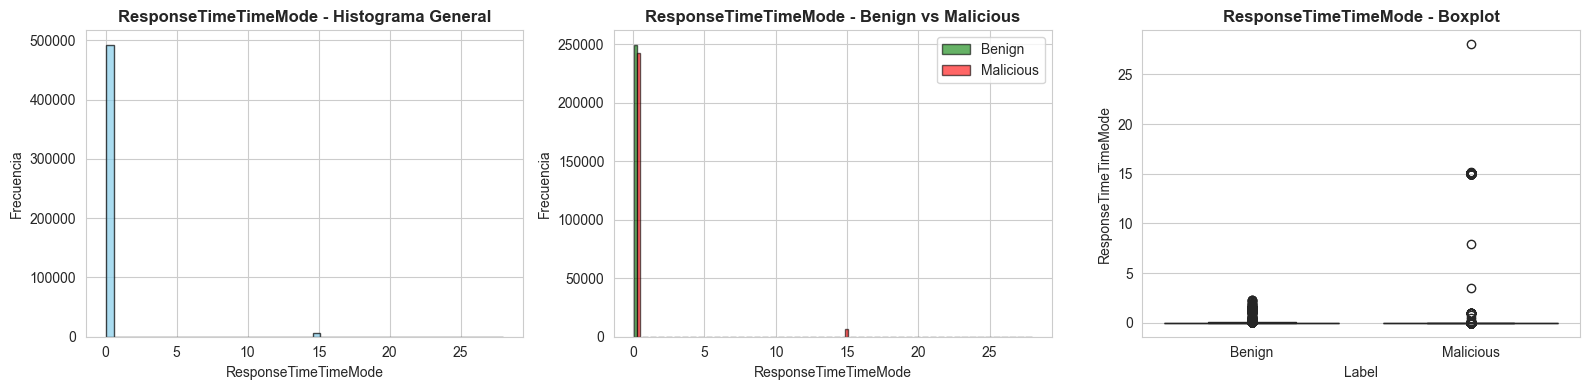

Benign - Mean: 0.01, Std: 0.04
Malicious - Mean: 0.40, Std: 2.42


In [53]:
"""
26
ResponseTimeTimeMode
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeMode']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeMode']

axes[0].hist(df['ResponseTimeTimeMode'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeMode - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeMode')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeMode - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeMode')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeMode', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeMode - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeMode')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\768039232.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeSkewFromMedian', ax=axes[2], palette=['green', 'red'])


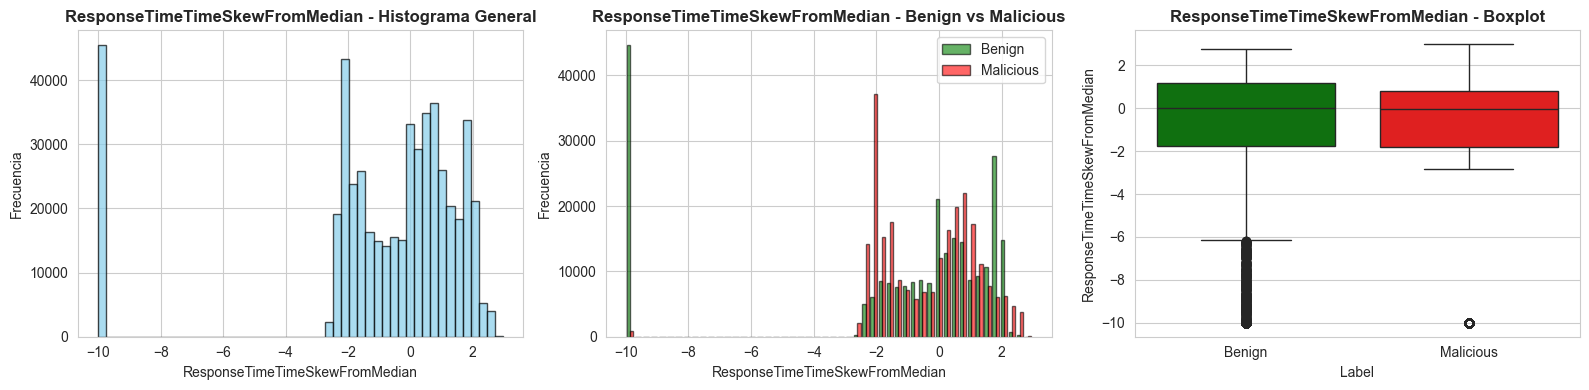

Benign - Mean: -1.58, Std: 4.11
Malicious - Mean: -0.35, Std: 1.54


In [54]:
"""
27
ResponseTimeTimeSkewFromMedian
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeSkewFromMedian']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeSkewFromMedian']

axes[0].hist(df['ResponseTimeTimeSkewFromMedian'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeSkewFromMedian - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeSkewFromMedian')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeSkewFromMedian - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeSkewFromMedian')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeSkewFromMedian', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeSkewFromMedian - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeSkewFromMedian')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\3288868888.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeSkewFromMode', ax=axes[2], palette=['green', 'red'])


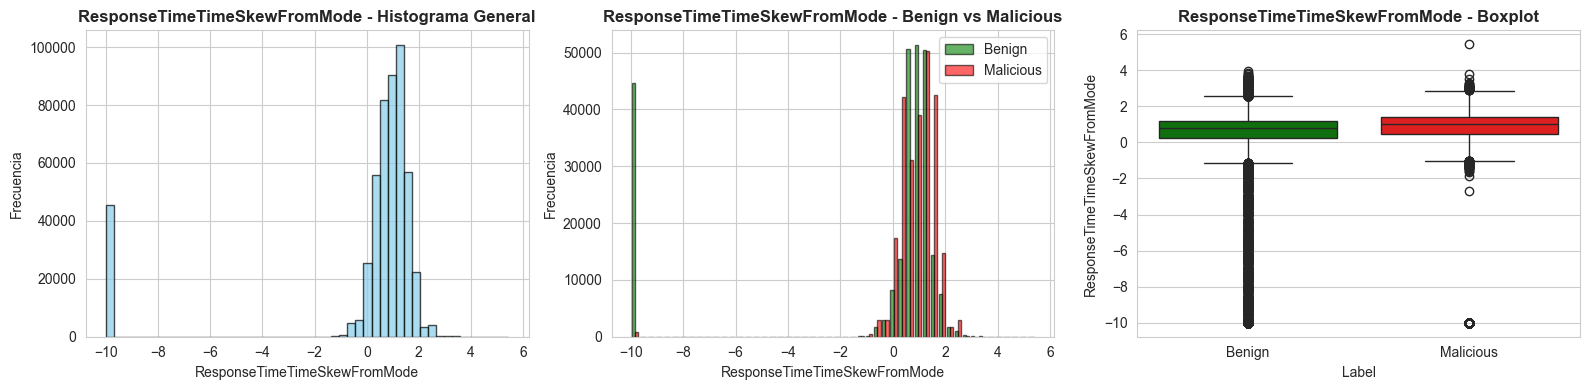

Benign - Mean: -1.03, Std: 4.23
Malicious - Mean: 0.91, Std: 0.85


In [55]:
"""
28
ResponseTimeTimeSkewFromMode
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeSkewFromMode']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeSkewFromMode']

axes[0].hist(df['ResponseTimeTimeSkewFromMode'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeSkewFromMode - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeSkewFromMode')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeSkewFromMode - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeSkewFromMode')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeSkewFromMode', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeSkewFromMode - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeSkewFromMode')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_6248\1427408794.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='ResponseTimeTimeCoefficientofVariation', ax=axes[2], palette=['green', 'red'])


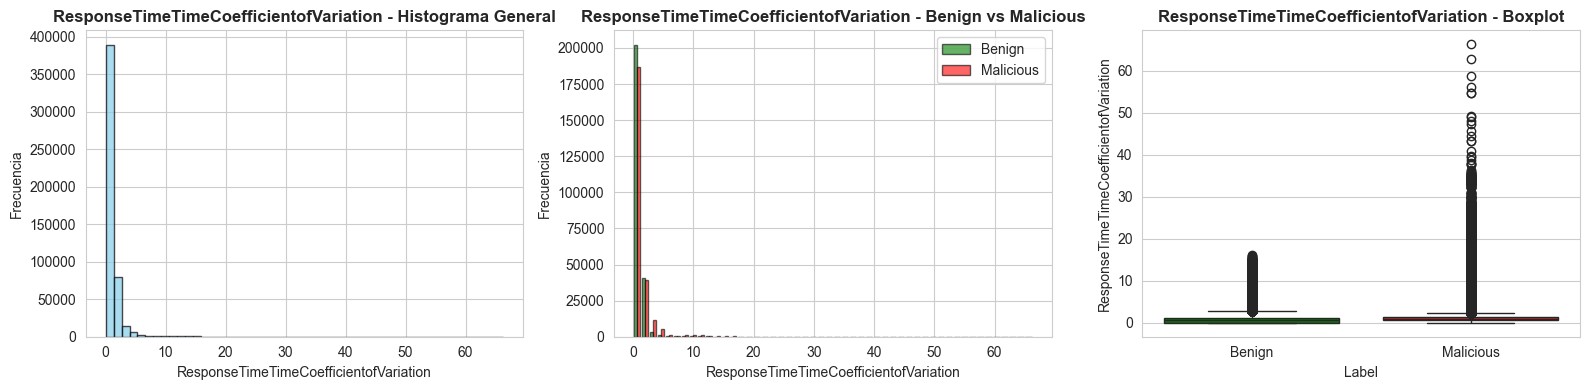

Benign - Mean: 0.84, Std: 1.04
Malicious - Mean: 1.39, Std: 2.19


In [56]:
"""
29
ResponseTimeTimeCoefficientofVariation
RESPONSE TIME FEATURES
"""

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_benign = df[df['Label'] == 'Benign']['ResponseTimeTimeCoefficientofVariation']
df_malicious = df[df['Label'] == 'Malicious']['ResponseTimeTimeCoefficientofVariation']

axes[0].hist(df['ResponseTimeTimeCoefficientofVariation'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('ResponseTimeTimeCoefficientofVariation - Histograma General', fontsize=12, fontweight='bold')
axes[0].set_xlabel('ResponseTimeTimeCoefficientofVariation')
axes[0].set_ylabel('Frecuencia')

axes[1].hist([df_benign, df_malicious], bins=50, label=['Benign', 'Malicious'], 
             color=['green', 'red'], alpha=0.6, edgecolor='black')
axes[1].set_title('ResponseTimeTimeCoefficientofVariation - Benign vs Malicious', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ResponseTimeTimeCoefficientofVariation')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

sns.boxplot(data=df, x='Label', y='ResponseTimeTimeCoefficientofVariation', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('ResponseTimeTimeCoefficientofVariation - Boxplot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ResponseTimeTimeCoefficientofVariation')

plt.tight_layout()
plt.show()

print(f"Benign - Mean: {df_benign.mean():.2f}, Std: {df_benign.std():.2f}")
print(f"Malicious - Mean: {df_malicious.mean():.2f}, Std: {df_malicious.std():.2f}")